# Regression & Classification — Intuition + Code
### Hack-o-Week | ArpitaBuilds

**Covers:** Linear Regression, Polynomial Regression, Ridge/Lasso → Logistic Regression, KNN

No proofs, all intuition + runnable code. Every section ties back to your **Explainable AI Stroke
Risk** project — stroke prediction is a **classification** problem (stroke / no stroke), and understanding
regression first makes classification click faster since logistic regression is regression's direct cousin.

**Why it matters for your project:**
- Your target (`stroke: 0 or 1`) → classification, not regression
- Logistic Regression = your simplest, most interpretable baseline model to compare XGBoost against
- Ridge/Lasso intuition = same regularization idea XGBoost uses internally (it penalizes complexity too)
- KNN = a good "sanity check" model — if it beats your fancy model, something's wrong


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.grid'] = True
PINK, BLUE, GRAY = '#ff2d78', '#2d9dff', '#888888'
print("Setup done ✅")

Setup done ✅


---
## 1. Linear Regression

Fits the **best straight line** through your data: `y = mx + c` (or `y = w·x + b` in ML notation).
"Best" means minimizing the sum of squared errors between the line and actual points — the same
gradient descent mechanism from your last notebook can find this `w` and `b`.

Learned: y = 2.76 * x + 7.54   (true was y = 3x + 7)


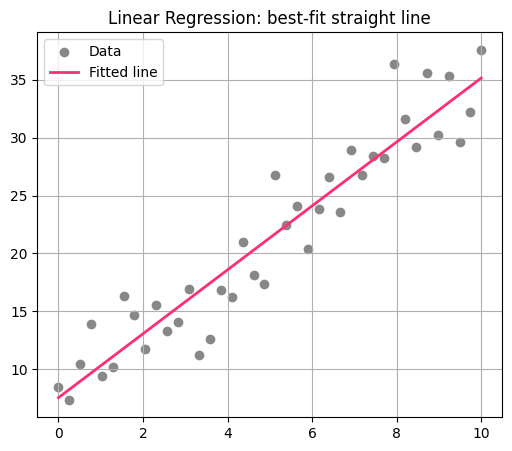

In [2]:
# Synthetic data: something roughly linear with noise
X = np.linspace(0, 10, 40).reshape(-1, 1)
y = 3 * X.flatten() + 7 + np.random.normal(0, 3, size=40)   # true relationship: y = 3x + 7 + noise

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print(f"Learned: y = {model.coef_[0]:.2f} * x + {model.intercept_:.2f}   (true was y = 3x + 7)")

plt.scatter(X, y, color=GRAY, label='Data')
plt.plot(X, y_pred, color=PINK, linewidth=2, label='Fitted line')
plt.legend(); plt.title("Linear Regression: best-fit straight line")
plt.show()

**Key takeaway:** Linear regression assumes a straight-line relationship. It learns exactly **one
weight per feature** — simple, fast, interpretable, but can't capture curves. Good starting baseline
for any numeric prediction (e.g. predicting a continuous risk *score* instead of a 0/1 label).

---
## 2. Polynomial Regression

Same idea as linear regression, but first **transform** x into `[x, x², x³, ...]` and then fit a
straight line on those — the line is straight in the new feature space, but curved in the original one.
Higher degree = more flexible curve, but also more risk of **overfitting** (memorizing noise instead
of learning the pattern).

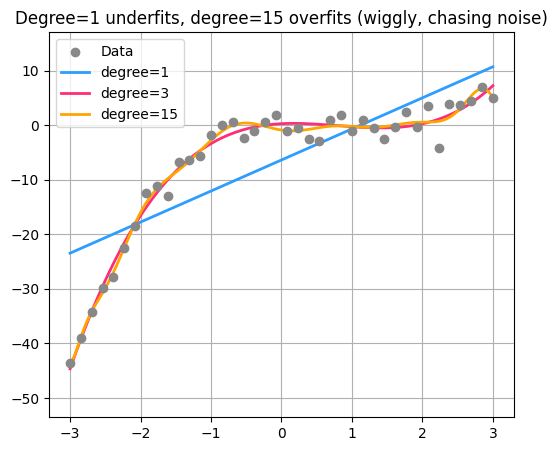

In [3]:
# Curved data
X = np.linspace(-3, 3, 40).reshape(-1, 1)
y = X.flatten()**3 - 2*X.flatten()**2 + np.random.normal(0, 2, size=40)

X_test = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, ax = plt.subplots()
ax.scatter(X, y, color=GRAY, label='Data', zorder=5)

for degree, color in zip([1, 3, 15], [BLUE, PINK, 'orange']):
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    poly_model.fit(X, y)
    y_test_pred = poly_model.predict(X_test)
    ax.plot(X_test, y_test_pred, color=color, linewidth=2, label=f'degree={degree}')

ax.set_ylim(y.min()-10, y.max()+10)
ax.legend(); ax.set_title("Degree=1 underfits, degree=15 overfits (wiggly, chasing noise)")
plt.show()

**Key takeaway:** degree=1 = too simple (underfitting), degree=15 = memorizes every noisy wiggle
(overfitting, won't generalize to new patients). Degree=3 here is the sweet spot. This exact
underfit/overfit tradeoff is why you tune `max_depth` in XGBoost — same problem, different knob.

---
## 3. Ridge & Lasso (Regularization)

Both add a **penalty for large weights** to the loss function so the model doesn't overfit:
- **Ridge (L2):** penalty = sum of squared weights → shrinks weights toward 0, rarely exactly 0
- **Lasso (L1):** penalty = sum of absolute weights → can push weights to **exactly 0**, effectively
  doing automatic feature selection (useless features get dropped)

`loss = prediction_error + alpha * penalty` — `alpha` controls how strong the penalty is.

True weights:  [ 5 -3  0  0  2  0  0  0  1  0]
Plain LR:      [ 5.15 -2.92  0.09  0.26  1.91  0.19  0.06 -0.16  1.12  0.12]
Ridge:         [ 4.47 -2.79 -0.01  0.07  1.76  0.23  0.18 -0.06  0.82  0.06]
Lasso:         [ 4.39 -2.79 -0.   -0.    1.42  0.    0.    0.    0.34 -0.  ]   <- notice zeros for useless features


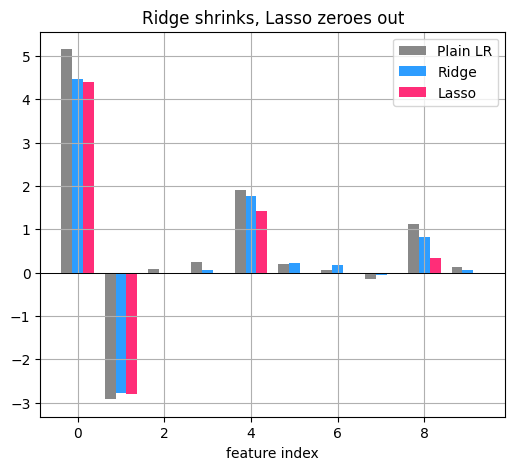

In [4]:
# Many features, some genuinely useless (to show Lasso zeroing them out)
np.random.seed(1)
n_samples, n_features = 50, 10
X = np.random.randn(n_samples, n_features)
true_weights = np.array([5, -3, 0, 0, 2, 0, 0, 0, 1, 0])   # only 4 features actually matter
y = X @ true_weights + np.random.normal(0, 1, n_samples)

plain = LinearRegression().fit(X, y)
ridge = Ridge(alpha=5.0).fit(X, y)
lasso = Lasso(alpha=0.5).fit(X, y)

print("True weights: ", true_weights)
print("Plain LR:     ", np.round(plain.coef_, 2))
print("Ridge:        ", np.round(ridge.coef_, 2))
print("Lasso:        ", np.round(lasso.coef_, 2), "  <- notice zeros for useless features")

fig, ax = plt.subplots()
width = 0.25
idx = np.arange(n_features)
ax.bar(idx - width, plain.coef_, width, label='Plain LR', color=GRAY)
ax.bar(idx, ridge.coef_, width, label='Ridge', color=BLUE)
ax.bar(idx + width, lasso.coef_, width, label='Lasso', color=PINK)
ax.axhline(0, color='black', lw=0.7)
ax.set_xlabel('feature index'); ax.legend(); ax.set_title("Ridge shrinks, Lasso zeroes out")
plt.show()

**Connects to your project:** if your stroke dataset has a feature that barely matters (say, a
redundant column), Lasso-style regularization would shrink its influence toward zero — same spirit as
XGBoost's built-in regularization terms (`reg_alpha`, `reg_lambda`) that keep trees from overfitting
to noisy features.

---
## 4. Logistic Regression (Classification, not Regression!)

Despite the name, this is a **classification** algorithm — exactly the kind you need for stroke
prediction (0 = no stroke, 1 = stroke).

It takes the linear regression idea (`z = w·x + b`) and squashes it through a **sigmoid function**
`σ(z) = 1/(1+e^-z)` to output a probability between 0 and 1. This is the exact same sigmoid from the
1-neuron backprop example in your last notebook.

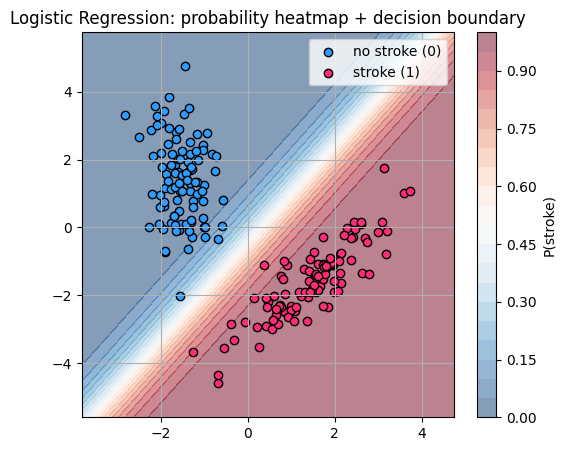

Learned weights: [[ 2.27281765 -1.59057154]]
Learned bias:    [-0.73653684]
Accuracy on this data: 1.0


In [5]:
# 2D synthetic classification data (like a simplified 2-feature stroke risk dataset)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                            n_clusters_per_class=1, class_sep=1.5, random_state=7)

logreg = LogisticRegression().fit(X, y)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                      np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z = logreg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots()
contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.5)
ax.scatter(X[y==0,0], X[y==0,1], color=BLUE, edgecolor='k', label='no stroke (0)')
ax.scatter(X[y==1,0], X[y==1,1], color=PINK, edgecolor='k', label='stroke (1)')
plt.colorbar(contour, label='P(stroke)')
ax.legend(); ax.set_title("Logistic Regression: probability heatmap + decision boundary")
plt.show()

print("Learned weights:", logreg.coef_)
print("Learned bias:   ", logreg.intercept_)
print("Accuracy on this data:", logreg.score(X, y))

**Key takeaway:** the color heatmap = predicted probability of stroke at every point. The boundary
where blue meets pink (P=0.5) is the **decision boundary**. This is literally your simplest possible
stroke-risk model — a great first baseline before jumping to XGBoost, and much easier to explain to a
non-technical audience ("higher BP + higher glucose = higher probability").

---
## 5. K-Nearest Neighbors (KNN)

No training/fitting at all — KNN just **remembers** all the data. To classify a new point, it looks at
the `k` closest existing points (using the same distance/magnitude idea from vectors in your last
notebook) and takes a majority vote.

`k` is the only real knob: small k = flexible but noisy (overfits), large k = smooth but can miss
local patterns (underfits).

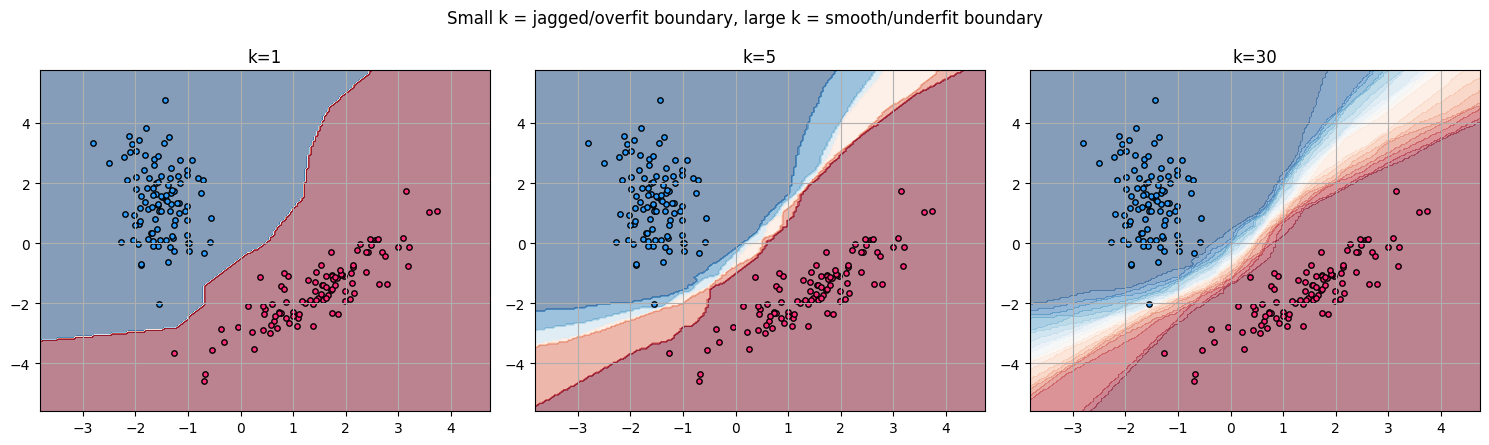

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, k in zip(axes, [1, 5, 30]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X, y)
    Z = knn.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.5)
    ax.scatter(X[y==0,0], X[y==0,1], color=BLUE, edgecolor='k', s=15)
    ax.scatter(X[y==1,0], X[y==1,1], color=PINK, edgecolor='k', s=15)
    ax.set_title(f"k={k}")

plt.suptitle("Small k = jagged/overfit boundary, large k = smooth/underfit boundary")
plt.tight_layout()
plt.show()

**Connects to your project:** KNN is a great sanity-check baseline — "if a model that just looks
at similar past patients (via cosine/Euclidean distance) already gets decent accuracy, my fancy XGBoost
model better beat it by a meaningful margin, or it's not worth the extra complexity."

Also notice: KNN literally uses the **dot product / distance** concept from your linear algebra
notebook to find "nearest" patients — the math notebooks aren't separate from this one, they're the
foundation under it.

---
## Recap Cheat Sheet

| Algorithm | Type | One-line intuition | Where it fits your project |
|---|---|---|---|
| Linear Regression | Regression | Best-fit straight line | Baseline for predicting a continuous risk score |
| Polynomial Regression | Regression | Straight line on transformed (curved) features | Shows underfit vs overfit tradeoff |
| Ridge (L2) | Regularization | Shrinks weights, keeps all features | Same spirit as XGBoost's `reg_lambda` |
| Lasso (L1) | Regularization | Shrinks weights to exactly 0 | Automatic feature selection |
| Logistic Regression | Classification | Sigmoid-squashed linear model → probability | Simplest interpretable stroke-risk baseline |
| KNN | Classification | Vote of k nearest neighbors, no real training | Sanity-check baseline, uses distance from linear algebra |

## Self-check (try before moving on)
1. Why is Logistic Regression called "regression" if it's used for classification?
2. What's the actual difference between what Ridge does vs what Lasso does to weights?
3. If your polynomial regression fits training data perfectly but does badly on new data, is that under- or overfitting?
4. Why does k=1 in KNN usually overfit?
5. Name one thing KNN and Logistic Regression both rely on from the linear algebra notebook.

## Next step
Try swapping the synthetic 2D data for 2 real columns from your stroke dataset (e.g. `age` and
`avg_glucose_level`) and rerun the Logistic Regression + KNN cells — you'll see your actual data's
decision boundary instead of synthetic data.
